In [ ]:
import os
notebook_dir = os.getcwd()
notebook_dir

In [ ]:
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
src_path = os.path.join(project_root)
src_path

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd

# ===============================================================
# DEFINIÇÕES DO DATASET
# ===============================================================
DATASET_DIR =  src_path + "/data/dataset_audio.csv"
SAMPLE_RATE = 22050

# ===============================================================
# PARÂMETROS DA TABELA — MFCC
# ===============================================================
MFCC_N_COEFFS = 13
MFCC_N_FILTERS = 32
MFCC_N_FFT = 256
MFCC_LOW_FREQ = 0
MFCC_HIGH_FREQ = None
MFCC_COEF = 0.98

# Ajuste necessário
MFCC_WIN_LENGTH = MFCC_N_FFT          # evita erro
MFCC_HOP_LENGTH = int(0.02 * SAMPLE_RATE)

# ===============================================================
# PARÂMETROS DA TABELA — MFE
# ===============================================================
MFE_N_FILTERS = 40
MFE_N_FFT = 256
MFE_LOW_FREQ = 0
MFE_HIGH_FREQ = None
MFE_NOISE_FLOOR = -52

# Ajuste necessário
MFE_WIN_LENGTH = MFE_N_FFT
MFE_HOP_LENGTH = int(0.01 * SAMPLE_RATE)


# ===============================================================
# VARIÁVEIS
# ===============================================================
data = []
label_map = {}
label_counter = 0


def extract_features(path):
    # Load
    signal, sr = librosa.load(path, sr=SAMPLE_RATE)

    # Pre-emphasis
    signal = np.append(signal[0], signal[1:] - MFCC_COEF * signal[:-1])

    # =======================================================
    # MFCC
    # =======================================================
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=MFCC_N_COEFFS,
        n_fft=MFCC_N_FFT,
        hop_length=MFCC_HOP_LENGTH,
        win_length=MFCC_WIN_LENGTH,
        n_mels=MFCC_N_FILTERS,
        fmin=MFCC_LOW_FREQ,
        fmax=MFCC_HIGH_FREQ
    )
    mfcc = librosa.util.normalize(mfcc, axis=1)

    # =======================================================
    # Mel Filterbank Energies (MFE)
    # =======================================================
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_fft=MFE_N_FFT,
        hop_length=MFE_HOP_LENGTH,
        win_length=MFE_WIN_LENGTH,
        n_mels=MFE_N_FILTERS,
        fmin=MFE_LOW_FREQ,
        fmax=MFE_HIGH_FREQ
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = np.maximum(mel_db, MFE_NOISE_FLOOR)

    return mfcc, mel_db


# ===============================================================
# LOOP DO DATASET
# ===============================================================
for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    if class_name not in label_map:
        label_map[class_name] = label_counter
        label_counter += 1

    for file_name in os.listdir(class_path):
        if file_name.endswith(".wav"):
            audio_path = os.path.join(class_path, file_name)

            mfcc, mfe = extract_features(audio_path)
            mfcc_flat = mfcc.reshape(-1)    # vector 1D
            mfe_flat  = mfe.reshape(-1)     # vector 1D

            data.append({
                "filename": file_name,
                "class": class_name,
                "label": label_map[class_name],
                "mfcc": mfcc,
                "mfe": mfe
            })


df = pd.DataFrame(data)

print(df.head())
print("\nLabel map:", label_map)
print("\nLinhas no DF:", len(df))


In [ ]:
df['mfcc'][0].shape

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mfcc_mfe_style(df, class_name, dpi=120):

    sample = df[df["class"] == class_name].iloc[0]

    mfcc = sample["mfcc"]
    mfe = sample["mfe"]

    # Calcula tempo no eixo X
    num_frames_mfcc = mfcc.shape[1]
    num_frames_mfe = mfe.shape[1]

    # Supondo stride = 0.01s
    time_mfcc = np.linspace(0, num_frames_mfcc * 0.01, num_frames_mfcc)
    time_mfe  = np.linspace(0, num_frames_mfe  * 0.01, num_frames_mfe)

    # ===========================
    #         PLOT MFCC
    # ===========================
    plt.figure(figsize=(10, 10), dpi=dpi)

    img = plt.imshow(
        mfcc,
        aspect='auto',
        origin='lower',
        extent=[time_mfcc.min(), time_mfcc.max(), 0, mfcc.shape[0]],
        cmap="turbo",
        alpha=0.95
    )

    # Aumenta fontes dos labels
    plt.xlabel("Time (s)", fontsize=16)
    plt.ylabel("MFCC Coefficient Index", fontsize=16)

    # Aumenta fonte dos ticks
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Colorbar com fonte maior
    cbar = plt.colorbar(img)
    cbar.set_label("MFCC Value", rotation=90, fontsize=16)
    cbar.ax.tick_params(labelsize=16)

    plt.grid(color='white', linestyle='-', linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.savefig(
        src_path + f"\\figures\\MFCC_{class_name}.pdf",
        dpi=300,
        format='pdf',
        bbox_inches='tight',
        pad_inches=0
    )
    plt.show()

    # ===========================
    #         PLOT MFE
    # ===========================
    plt.figure(figsize=(10, 10), dpi=dpi)

    img = plt.imshow(
        mfe,
        aspect='auto',
        origin='lower',
        extent=[time_mfe.min(), time_mfe.max(), 0, mfe.shape[0]],
        cmap="turbo",
        alpha=0.95
    )

    plt.xlabel("Time (s)", fontsize=16)
    plt.ylabel("Mel Filter Index", fontsize=16)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    cbar = plt.colorbar(img)
    cbar.set_label("Energy (dB)", rotation=90, fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    plt.grid(color='white', linestyle='-', linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.savefig(
        src_path + f"\\figures\\MFE_{class_name}.pdf",
        dpi=300,
        format='pdf',
        bbox_inches='tight',
        pad_inches=0
    )
    plt.show()


In [ ]:
df["class"].unique()

In [ ]:
for cls in df["class"].unique():
    plot_mfcc_mfe_style(df, cls)


In [ ]:
df = pd.DataFrame(data)

# ===============================================================
# ONE-HOT ENCODING DAS CLASSES
# ===============================================================
one_hot = pd.get_dummies(df["class"], prefix="class").astype(int)

df = pd.concat([df, one_hot], axis=1)

print(df.head())
print("\nLabel map:", label_map)
print("\nLinhas no DF:", len(df))
print("\nColunas one-hot:", one_hot.columns.tolist())


In [ ]:
df['mfcc'] = df['mfcc'].values.reshape(-1)    # vector 1D
df['mfe']   = df['mfe'].values.reshape(-1)     # vector 1D

In [ ]:
# ===============================================================
# SALVAR DATASET EM CSV
# ===============================================================
output_path = src_path + "\\data\\dataset_audio.csv"

# Observação importante:
# mfcc e mfe são arrays — iremos salvar como strings.
df.to_csv(output_path, index=False)

print(f"\nCSV salvo com sucesso em: {output_path}")


In [ ]:
import os
import numpy as np
import librosa
import pandas as pd
from tqdm import tqdm

# ================================
# CONFIGURAÇÕES
# ================================
DATASET_PATH = "C:\\Users\\thomm\\OneDrive\\Desktop\\FAN_PAPER\\Base_de_Dados_0\\Base_de_Dados"
SAMPLE_RATE = 16000
WINDOW_SIZE = 0.5  # 500 ms

# ================================
# MFCC CONFIG (120 features)
# ================================
MFCC_CONFIG = {
    "n_mfcc": 30,
    "n_mels": 40,
    "frame_length": 0.025,
    "frame_stride": 0.010,
    "n_fft": 512,
    "fmin": 20,
    "fmax": 4000
}

# ================================
# MFE CONFIG (120 features)
# ================================
MFE_CONFIG = {
    "n_mels": 30,
    "frame_length": 0.025,
    "frame_stride": 0.010,
    "n_fft": 512,
    "fmin": 20,
    "fmax": 4000,
    "noise_floor_db": -50
}

# ================================
# FUNÇÃO SPLIT AUDIO
# ================================

def split_audio(signal, sr):

    window_samples = int(WINDOW_SIZE * sr)

    segments = []

    for i in range(0, len(signal) - window_samples + 1, window_samples):
        segments.append(signal[i:i + window_samples])

    return segments


# ================================
# MFCC FEATURES
# ================================

def extract_mfcc_features(signal, sr):

    hop_length = int(sr * MFCC_CONFIG["frame_stride"])
    win_length = int(sr * MFCC_CONFIG["frame_length"])

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=MFCC_CONFIG["n_mfcc"],
        n_fft=MFCC_CONFIG["n_fft"],
        hop_length=hop_length,
        win_length=win_length,
        n_mels=MFCC_CONFIG["n_mels"],
        fmin=MFCC_CONFIG["fmin"],
        fmax=MFCC_CONFIG["fmax"]
    )

    delta = librosa.feature.delta(mfcc)

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    delta_mean = np.mean(delta, axis=1)
    delta_std = np.std(delta, axis=1)

    return np.concatenate([mfcc_mean, mfcc_std, delta_mean, delta_std])


# ================================
# MFE FEATURES
# ================================

def extract_mfe_features(signal, sr):

    hop_length = int(sr * MFE_CONFIG["frame_stride"])
    win_length = int(sr * MFE_CONFIG["frame_length"])

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_fft=MFE_CONFIG["n_fft"],
        hop_length=hop_length,
        win_length=win_length,
        n_mels=MFE_CONFIG["n_mels"],
        fmin=MFE_CONFIG["fmin"],
        fmax=MFE_CONFIG["fmax"]
    )

    mel_db = librosa.power_to_db(mel)

    mel_db = np.maximum(mel_db, MFE_CONFIG["noise_floor_db"])

    delta = librosa.feature.delta(mel_db)

    mel_mean = np.mean(mel_db, axis=1)
    mel_std = np.std(mel_db, axis=1)

    delta_mean = np.mean(delta, axis=1)
    delta_std = np.std(delta, axis=1)

    return np.concatenate([mel_mean, mel_std, delta_mean, delta_std])


# ================================
# CLASSES
# ================================

classes = sorted(os.listdir(DATASET_PATH))
classes = [c for c in classes if os.path.isdir(os.path.join(DATASET_PATH, c))]

num_classes = len(classes)

print("Classes encontradas:")
for i, c in enumerate(classes):
    print(i, c)

mfcc_rows = []
mfe_rows = []

# ================================
# PROCESSAMENTO
# ================================

for class_index, cls in enumerate(classes):

    folder = os.path.join(DATASET_PATH, cls)

    files = [f for f in os.listdir(folder) if f.endswith(".wav")]

    for file in tqdm(files, desc=f"Processing {cls}"):

        path = os.path.join(folder, file)

        signal, sr = librosa.load(path, sr=SAMPLE_RATE)

        segments = split_audio(signal, sr)

        for segment in segments:

            mfcc = extract_mfcc_features(segment, sr)
            mfe = extract_mfe_features(segment, sr)

            label = np.zeros(num_classes)
            label[class_index] = 1

            mfcc_rows.append(np.concatenate([mfcc, label]))
            mfe_rows.append(np.concatenate([mfe, label]))

# ================================
# DATAFRAMES
# ================================

mfcc_rows = np.array(mfcc_rows)
mfe_rows = np.array(mfe_rows)

mfcc_features = mfcc_rows.shape[1] - num_classes
mfe_features = mfe_rows.shape[1] - num_classes

mfcc_cols = [f"mfcc_{i}" for i in range(mfcc_features)] + classes
mfe_cols = [f"mfe_{i}" for i in range(mfe_features)] + classes

df_mfcc = pd.DataFrame(mfcc_rows, columns=mfcc_cols)
df_mfe = pd.DataFrame(mfe_rows, columns=mfe_cols)

# ================================
# EXPORT CSV
# ================================

df_mfcc.to_csv("mfcc_dataset_onehot.csv", index=False)
df_mfe.to_csv("mfe_dataset_onehot.csv", index=False)

print("\nDatasets salvos!")
print("MFCC shape:", df_mfcc.shape)
print("MFE shape:", df_mfe.shape)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# CONFIG
# =========================

MFCC_CSV = "mfcc_dataset_onehot.csv"
MFE_CSV = "mfe_dataset_onehot.csv"

OUTPUT_FOLDER = "plots"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# =========================
# LOAD DATA
# =========================

mfcc_df = pd.read_csv(MFCC_CSV)
mfe_df = pd.read_csv(MFE_CSV)

# detect one-hot columns automatically
def split_features_labels(df):

    data = df.values

    # one-hot columns are only 0 or 1
    onehot_mask = np.all(np.logical_or(data == 0, data == 1), axis=0)

    # assume last contiguous block are labels
    label_start = np.where(onehot_mask)[0][0]

    features = data[:, :label_start]
    labels = data[:, label_start:]

    return features, labels

mfcc_features, labels = split_features_labels(mfcc_df)
mfe_features, _ = split_features_labels(mfe_df)

print("MFCC feature shape:", mfcc_features.shape)
print("MFE feature shape:", mfe_features.shape)

num_classes = labels.shape[1]
classes = np.argmax(labels, axis=1)

# =========================
# DETERMINE RESHAPE SIZE
# =========================

num_features = mfcc_features.shape[1]

# try to make a rectangular matrix
stats = 4
coeffs = num_features // stats

print("Coefficients:", coeffs)
print("Statistics:", stats)

# =========================
# PLOT FUNCTION
# =========================

def plot_heatmap(matrix, title, filename):

    plt.figure(figsize=(5,4))

    plt.imshow(
        matrix,
        aspect='auto',
        origin='lower',
        cmap='turbo'
    )

    plt.xlabel("Statistics")
    plt.ylabel("Coefficient Index")

    cbar = plt.colorbar()
    cbar.set_label("Feature Value")

    #plt.title(title)

    plt.tight_layout()
    plt.savefig(filename, format="pdf", dpi=300)
    plt.close()

# =========================
# ONE SAMPLE PER CLASS
# =========================

unique_classes = np.unique(classes)

for c in unique_classes:

    idx = np.where(classes == c)[0][0]

    mfcc_sample = mfcc_features[idx].reshape(coeffs, stats)
    mfe_sample = mfe_features[idx].reshape(coeffs, stats)

    plot_heatmap(
        mfcc_sample,
        f"MFCC Representation - Class {c}",
        f"{OUTPUT_FOLDER}/class_{c}_mfcc.pdf"
    )

    plot_heatmap(
        mfe_sample,
        f"MFE Representation - Class {c}",
        f"{OUTPUT_FOLDER}/class_{c}_mfe.pdf"
    )

print("Plots saved in:", OUTPUT_FOLDER)

MFCC feature shape: (4296, 120)
MFE feature shape: (4296, 120)
Coefficients: 30
Statistics: 4
Plots saved in: plots


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# CONFIG
# =========================

MFCC_CSV = "mfcc_dataset_onehot.csv"
MFE_CSV = "mfe_dataset_onehot.csv"

OUTPUT_FOLDER = "plots"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

plt.style.use("seaborn-v0_8-paper")

# =========================
# LOAD DATA
# =========================

mfcc_df = pd.read_csv(MFCC_CSV)
mfe_df = pd.read_csv(MFE_CSV)

def split_features_labels(df):
    data = df.values
    onehot_mask = np.all(np.logical_or(data == 0, data == 1), axis=0)
    label_start = np.where(onehot_mask)[0][0]

    features = data[:, :label_start]
    labels = data[:, label_start:]
    return features, labels

mfcc_features, labels = split_features_labels(mfcc_df)
mfe_features, _ = split_features_labels(mfe_df)

print("MFCC feature shape:", mfcc_features.shape)
print("MFE feature shape:", mfe_features.shape)

classes = np.argmax(labels, axis=1)

# =========================
# RESHAPE PARA TEMPO REAL
# =========================

num_features = mfcc_features.shape[1]

# DEFINA corretamente (ajuste se necessário)
n_coeffs = 13  # típico para MFCC (pode ser 20, 40, etc.)
n_frames = num_features // n_coeffs

print("Frames (time):", n_frames)
print("Coefficients:", n_coeffs)

# =========================
# NORMALIZAÇÃO GLOBAL
# =========================

global_min = min(mfcc_features.min(), mfe_features.min())
global_max = max(mfcc_features.max(), mfe_features.max())

# =========================
# PLOT FUNCTION
# =========================

def plot_heatmap(matrix, filename):

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        matrix,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        vmin=global_min,
        vmax=global_max
    )

    ax.set_xlabel("Time (Frames)", fontsize=10)
    ax.set_ylabel("Coefficient Index", fontsize=10)

    # ticks mais organizados
    ax.set_xticks(np.linspace(0, matrix.shape[1]-1, 6, dtype=int))
    ax.set_yticks(np.linspace(0, matrix.shape[0]-1, 6, dtype=int))

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Feature Value", fontsize=9)

    plt.tight_layout()
    plt.savefig(filename, format="pdf", dpi=600)
    plt.close()

# =========================
# UMA AMOSTRA POR CLASSE
# =========================

unique_classes = np.unique(classes)

for c in unique_classes:

    idx = np.where(classes == c)[0][0]

    # reshape correto: (frames, coeffs) -> transpose
    mfcc_sample = mfcc_features[idx].reshape(n_frames, n_coeffs).T
    mfe_sample = mfe_features[idx].reshape(n_frames, n_coeffs).T

    plot_heatmap(
        mfcc_sample,
        f"{OUTPUT_FOLDER}/class_{c}_mfcc.pdf"
    )

    plot_heatmap(
        mfe_sample,
        f"{OUTPUT_FOLDER}/class_{c}_mfe.pdf"
    )

print("Plots saved in:", OUTPUT_FOLDER)

MFCC feature shape: (4296, 120)
MFE feature shape: (4296, 120)
Frames (time): 9
Coefficients: 13


ValueError: cannot reshape array of size 120 into shape (9,13)

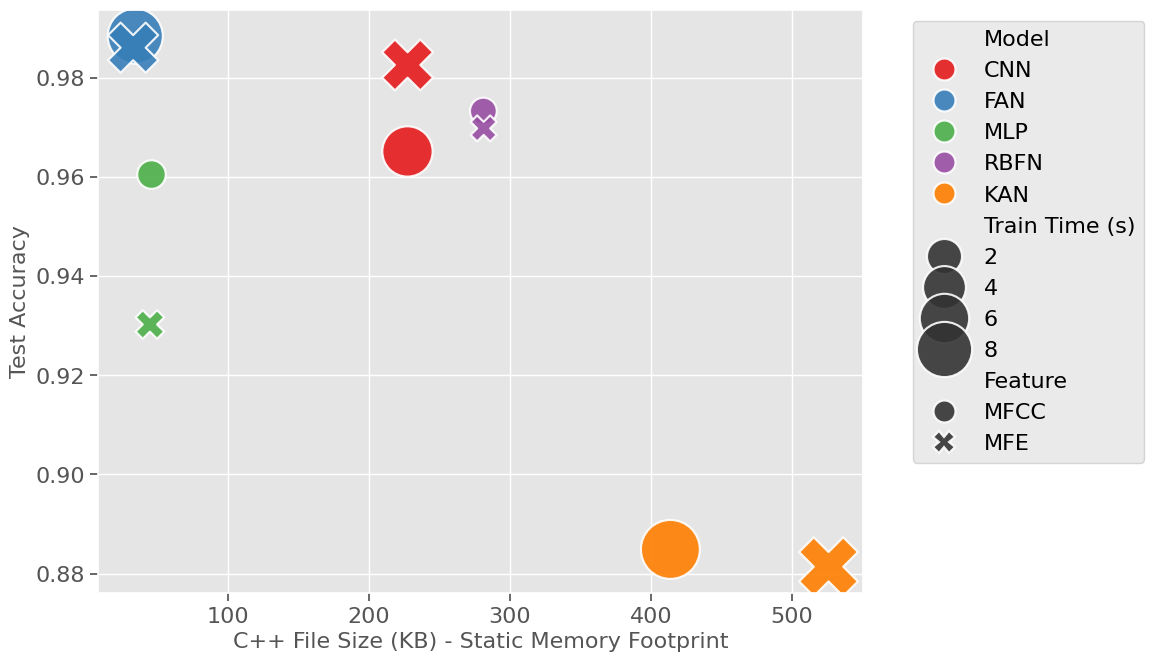

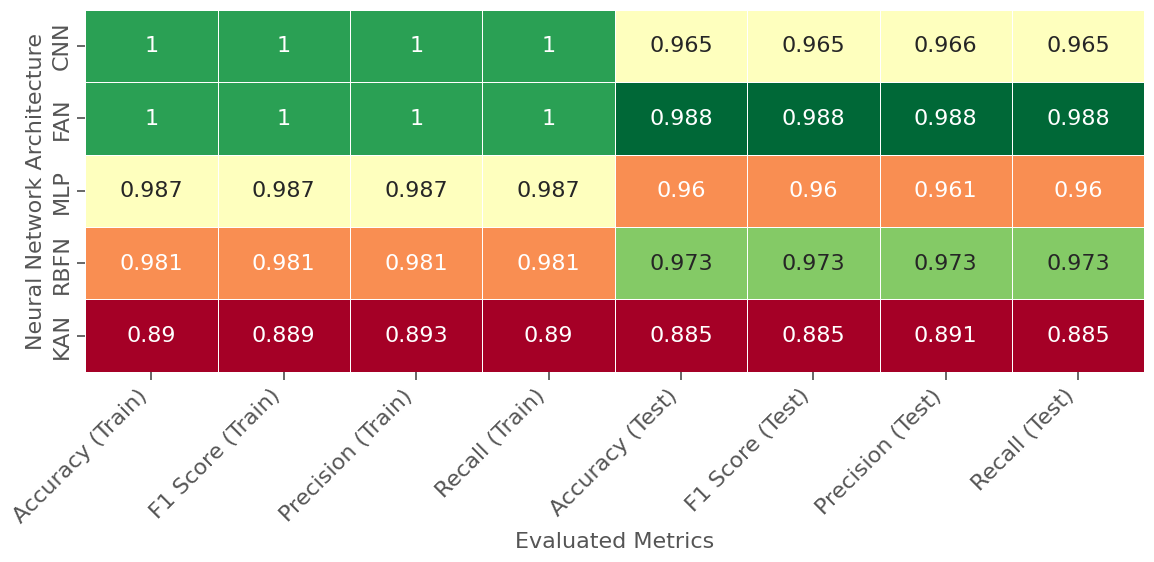

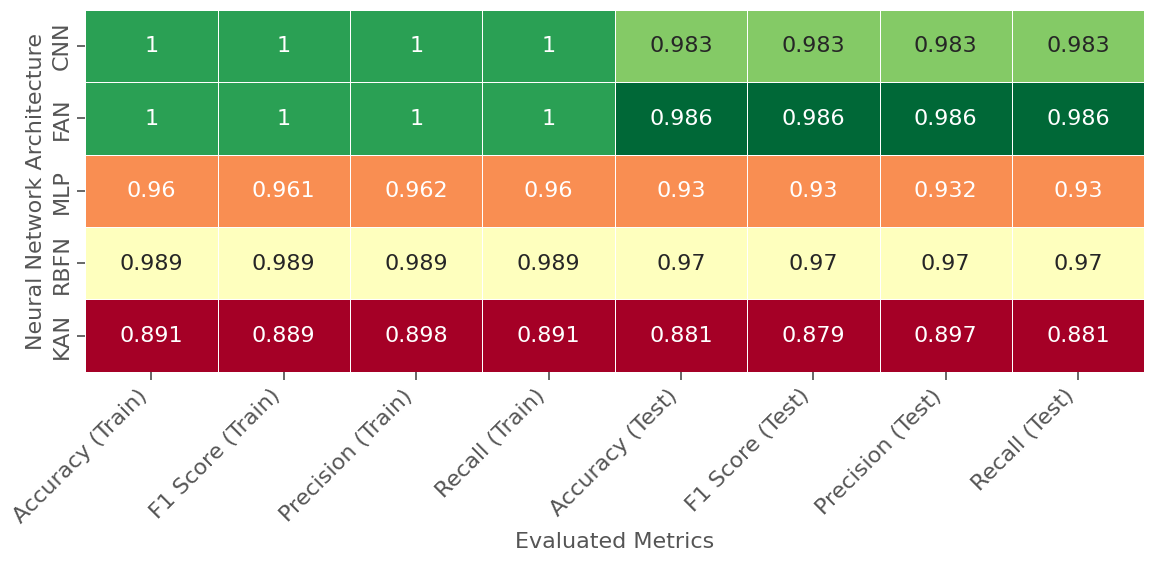

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# ---------------------------------------------------------
# STYLE: ggplot + FONT = 16
# ---------------------------------------------------------
plt.style.use('ggplot')

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})

sns.set_theme(context="notebook", font_scale=1.6, style=None)

# ---------------------------------------------------------
# DATA LOADING
# ---------------------------------------------------------
files = [
    "resultados_sweep_cnn_clean.csv", 
    "resultados_sweep_fan_clean.csv", 
    "resultados_sweep_mlp_clean.csv", 
    "resultados_sweep_rbfn_clean.csv", 
    "resultados_sweep_kan_clean.csv"
]

best_models = []

for f in files:
    df = pd.read_csv(f)
    
    acc_test_col = [c for c in df.columns if 'Accuracy' in c and 'Test' in c][0]
    f1_test_col = [c for c in df.columns if 'F1 Score' in c and 'Test' in c][0]
    prec_test_col = [c for c in df.columns if 'Precision' in c and 'Test' in c][0]
    rec_test_col = [c for c in df.columns if 'Recall' in c and 'Test' in c][0]
    
    acc_train_col = [c for c in df.columns if 'Accuracy' in c and 'Train' in c][0]
    f1_train_col = [c for c in df.columns if 'F1 Score' in c and 'Train' in c][0]
    prec_train_col = [c for c in df.columns if 'Precision' in c and 'Train' in c][0]
    rec_train_col = [c for c in df.columns if 'Recall' in c and 'Train' in c][0]
    
    feat_col = 'Feature type' if 'Feature type' in df.columns else 'feature_type'
    
    for feat in ['MFCC', 'MFE']:
        df_feat = df[df[feat_col] == feat]
        if not df_feat.empty:
            best_idx = df_feat[acc_test_col].idxmax()
            best_row = df_feat.loc[best_idx]
            
            best_models.append({
                'Model': best_row['model_name'],
                'Feature': feat,
                'Accuracy (Train)': best_row[acc_train_col],
                'F1 Score (Train)': best_row[f1_train_col],
                'Precision (Train)': best_row[prec_train_col],
                'Recall (Train)': best_row[rec_train_col],
                'Accuracy (Test)': best_row[acc_test_col],
                'F1 Score (Test)': best_row[f1_test_col],
                'Precision (Test)': best_row[prec_test_col],
                'Recall (Test)': best_row[rec_test_col],
                'Memory (KB)': best_row['C++ File Size (B)'] / 1024,
                'Train Time (s)': best_row['Training Time (s)']
            })

best_df = pd.DataFrame(best_models)

# ---------------------------------------------------------
# 1. BUBBLE CHART
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=best_df, 
    x='Memory (KB)', 
    y='Accuracy (Test)', 
    hue='Model', 
    style='Feature',
    size='Train Time (s)', 
    sizes=(350, 1800),   # 🔵 bigger bubbles
    s=250,               # ✖️ bigger markers (circle/X)
    alpha=0.9, 
    palette='Set1'
)

# Force tick size
ax.tick_params(axis='both', labelsize=16)

# Labels near bubbles
#for i, row in best_df.iterrows():
#    plt.text(
#        row['Memory (KB)'] + 5,
#        row['Accuracy (Test)'],
#        f"{row['Model']}\n({row['Feature']})",
#        fontsize=16,
#        fontweight='bold'
#    )

plt.xlabel('C++ File Size (KB) - Static Memory Footprint', fontsize=16)
plt.ylabel('Test Accuracy', fontsize=16)

# Legend adjustment (VERY IMPORTANT)
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

for handle in legend.legend_handles:
    try:
        handle.set_sizes([250])  # increase legend marker size
    except:
        pass

plt.tight_layout()
plt.savefig('bubble_chart_tinyml.pdf', dpi=300)
plt.show()

# ---------------------------------------------------------
# 2. HEATMAPS
# ---------------------------------------------------------
metrics_cols = [
    'Accuracy (Train)', 'F1 Score (Train)', 'Precision (Train)', 'Recall (Train)',
    'Accuracy (Test)', 'F1 Score (Test)', 'Precision (Test)', 'Recall (Test)'
]

def plot_heatmap(df_subset, filename):
    plt.figure(figsize=(12, 6))
    
    heatmap_data = df_subset.set_index('Model')[metrics_cols]
    
    rank_df = pd.DataFrame(index=heatmap_data.index)
    
    for col in metrics_cols:
        rank_df[col] = heatmap_data[col].rank(ascending=True)

    ax = sns.heatmap(
        rank_df,
        annot=heatmap_data.round(3),
        cmap='RdYlGn',
        fmt='g',
        cbar=False,
        linewidths=.5,
        annot_kws={"size": 16}
    )

    ax.tick_params(axis='both', labelsize=16)

    plt.xlabel('Evaluated Metrics', fontsize=16)
    plt.ylabel('Neural Network Architecture', fontsize=16)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# MFCC
plot_heatmap(
    df_subset=best_df[best_df['Feature'] == 'MFCC'],
    filename='heatmap_mfcc.pdf'
)

# MFE
plot_heatmap(
    df_subset=best_df[best_df['Feature'] == 'MFE'],
    filename='heatmap_mfe.pdf'
)

In [ ]:
import re

def count_parameters_cpp(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Regex para capturar arrays de floats
    pattern = re.compile(r'const float\s+\w+\[\]\s+PROGMEM\s*=\s*\{([^}]*)\}', re.DOTALL)

    matches = pattern.findall(content)

    total_params = 0
    layer_details = {}

    for i, match in enumerate(matches):
        # Conta números float dentro do array
        numbers = re.findall(r'[-+]?\d*\.\d+f?', match)
        count = len(numbers)

        layer_name = f"layer_{i}"
        layer_details[layer_name] = count
        total_params += count

    return total_params, layer_details


def count_parameters_from_header(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Extrai informações estruturais (opcional)
    params = {}

    patterns = {
        "conv0_weights": r'CONV0_NUM_FILTERS\s*\*\s*\d+',  # opcional
        "dense0": r'#define\s+DENSE0_INPUT_SIZE\s+(\d+).*?#define\s+DENSE0_OUTPUT_SIZE\s+(\d+)',
    }

    # Dense layer (mais confiável)
    dense_match = re.search(patterns["dense0"], content, re.DOTALL)
    if dense_match:
        in_size = int(dense_match.group(1))
        out_size = int(dense_match.group(2))

        weights = in_size * out_size
        bias = out_size

        params["dense0_weights_calc"] = weights
        params["dense0_bias_calc"] = bias
        params["dense0_total_calc"] = weights + bias

    return params


if __name__ == "__main__":
    cpp_file = "neural_network.cpp"
    h_file = "neural_network.h"

    total_cpp, details = count_parameters_cpp(cpp_file)
    header_info = count_parameters_from_header(h_file)

    print("=== Contagem direta do .cpp ===")
    for k, v in details.items():
        print(f"{k}: {v} parâmetros")

    print(f"\nTotal (CPP): {total_cpp} parâmetros")

    print("\n=== Estimativa via .h (estrutura) ===")
    for k, v in header_info.items():
        print(f"{k}: {v}")

In [ ]:
import re

def count_parameters_from_arrays(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Captura arrays de float (multi-linha)
    pattern = re.compile(
        r'(?:const\s+)?float\s+(\w+)\s*\[.*?\]\s*=\s*\{([^}]*)\}',
        re.DOTALL
    )

    matches = pattern.findall(content)

    total_params = 0
    details = {}

    for name, values_block in matches:
        # Captura números float (com ou sem 'f')
        numbers = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?f?', values_block)

        count = len(numbers)
        details[name] = count
        total_params += count

    return total_params, details


if __name__ == "__main__":
    total, details = count_parameters_from_arrays("fan_model.h")

    print("=== Parâmetros por variável ===")
    for k, v in details.items():
        print(f"{k}: {v}")

    print(f"\nTOTAL: {total} parâmetros")

In [ ]:
import re

def count_mlp_parameters(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # 🔥 Captura arrays completos (mesmo com várias linhas)
    pattern = re.compile(
        r'(?:const\s+)?float\s+(\w+)\s*\[.*?\]\s*=\s*\{([\s\S]*?)\};',
        re.DOTALL
    )

    matches = pattern.findall(content)

    total_params = 0
    details = {}

    for name, values_block in matches:
        # captura qualquer número válido
        numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?f?', values_block)

        count = len(numbers)
        details[name] = count
        total_params += count

    return total_params, details


if __name__ == "__main__":
    total, details = count_mlp_parameters("MLP.h")

    print("=== Parâmetros por variável ===")
    for k, v in details.items():
        print(f"{k}: {v}")

    print(f"\nTOTAL: {total}")

In [ ]:
import re

def count_parameters_kan(header_path):
    with open(header_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # -------------------------------
    # 🔢 Padrões de números float
    # -------------------------------
    float_pattern = r'[-+]?\d*\.\d+(?:e[-+]?\d+)?'

    # -------------------------------
    # 📌 1. Coeficientes tipo: a * x_i
    # -------------------------------
    linear_terms = re.findall(rf'({float_pattern})\s*\*\s*x_\d+', content)

    # -------------------------------
    # 📌 2. Coeficientes em pow()
    # -------------------------------
    pow_terms = re.findall(rf'({float_pattern})\s*\*\s*std::pow', content)

    # -------------------------------
    # 📌 3. Constantes somadas (bias-like)
    # -------------------------------
    bias_terms = re.findall(rf'[\+\-]\s*({float_pattern})(?!\s*\*)', content)

    # -------------------------------
    # 🔢 Contagem total
    # -------------------------------
    total = len(linear_terms) + len(pow_terms) + len(bias_terms)

    print("=== Parameter Count (KAN) ===")
    print(f"Linear terms   : {len(linear_terms)}")
    print(f"Pow terms      : {len(pow_terms)}")
    print(f"Bias/constants : {len(bias_terms)}")
    print(f"TOTAL          : {total}")

    return total

count_parameters_kan("kan_model.h")

In [ ]:
import re
import os


def read_files(file_paths):
    content = ""
    loaded_files = []

    for path in file_paths:
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                content += f.read() + "\n"
                loaded_files.append(path)
        else:
            print(f"[WARNING] File not found: {path}")

    if not loaded_files:
        raise FileNotFoundError("Nenhum arquivo válido encontrado.")

    print("Arquivos carregados:", loaded_files)
    return content


def extract_arrays(content):
    pattern = re.compile(
        r'(?:const\s+)?float\s+(\w+)\s*\[.*?\]\s*(?:PROGMEM)?\s*=\s*\{([\s\S]*?)\};',
        re.DOTALL
    )
    return pattern.findall(content)


def count_numbers(values_block):
    numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?f?', values_block)
    return len(numbers)


def classify_param(name):
    name = name.lower()

    if "bias" in name or name.startswith("b"):
        return "bias"
    elif "weight" in name or name.startswith("w"):
        return "weight"
    elif "center" in name or "mu" in name:
        return "rbf_center"
    elif "sigma" in name or "gamma" in name:
        return "rbf_width"
    else:
        return "unknown"


def count_parameters(file_paths):
    content = read_files(file_paths)
    arrays = extract_arrays(content)

    total = 0
    summary = {
        "weight": 0,
        "bias": 0,
        "rbf_center": 0,
        "rbf_width": 0,
        "unknown": 0
    }

    details = {}

    for name, block in arrays:
        count = count_numbers(block)
        param_type = classify_param(name)

        details[name] = {
            "count": count,
            "type": param_type
        }

        total += count
        summary[param_type] += count

    return total, summary, details


if __name__ == "__main__":
    files = ["RbfModelRBF.h", "RbfModelRBF.cpp"]

    total, summary, details = count_parameters(files)

    print("\n=== Parâmetros por variável ===")
    for name, info in details.items():
        print(f"{name}: {info['count']} ({info['type']})")

    print("\n=== Resumo ===")
    for k, v in summary.items():
        print(f"{k}: {v}")

    print(f"\nTOTAL: {total}")

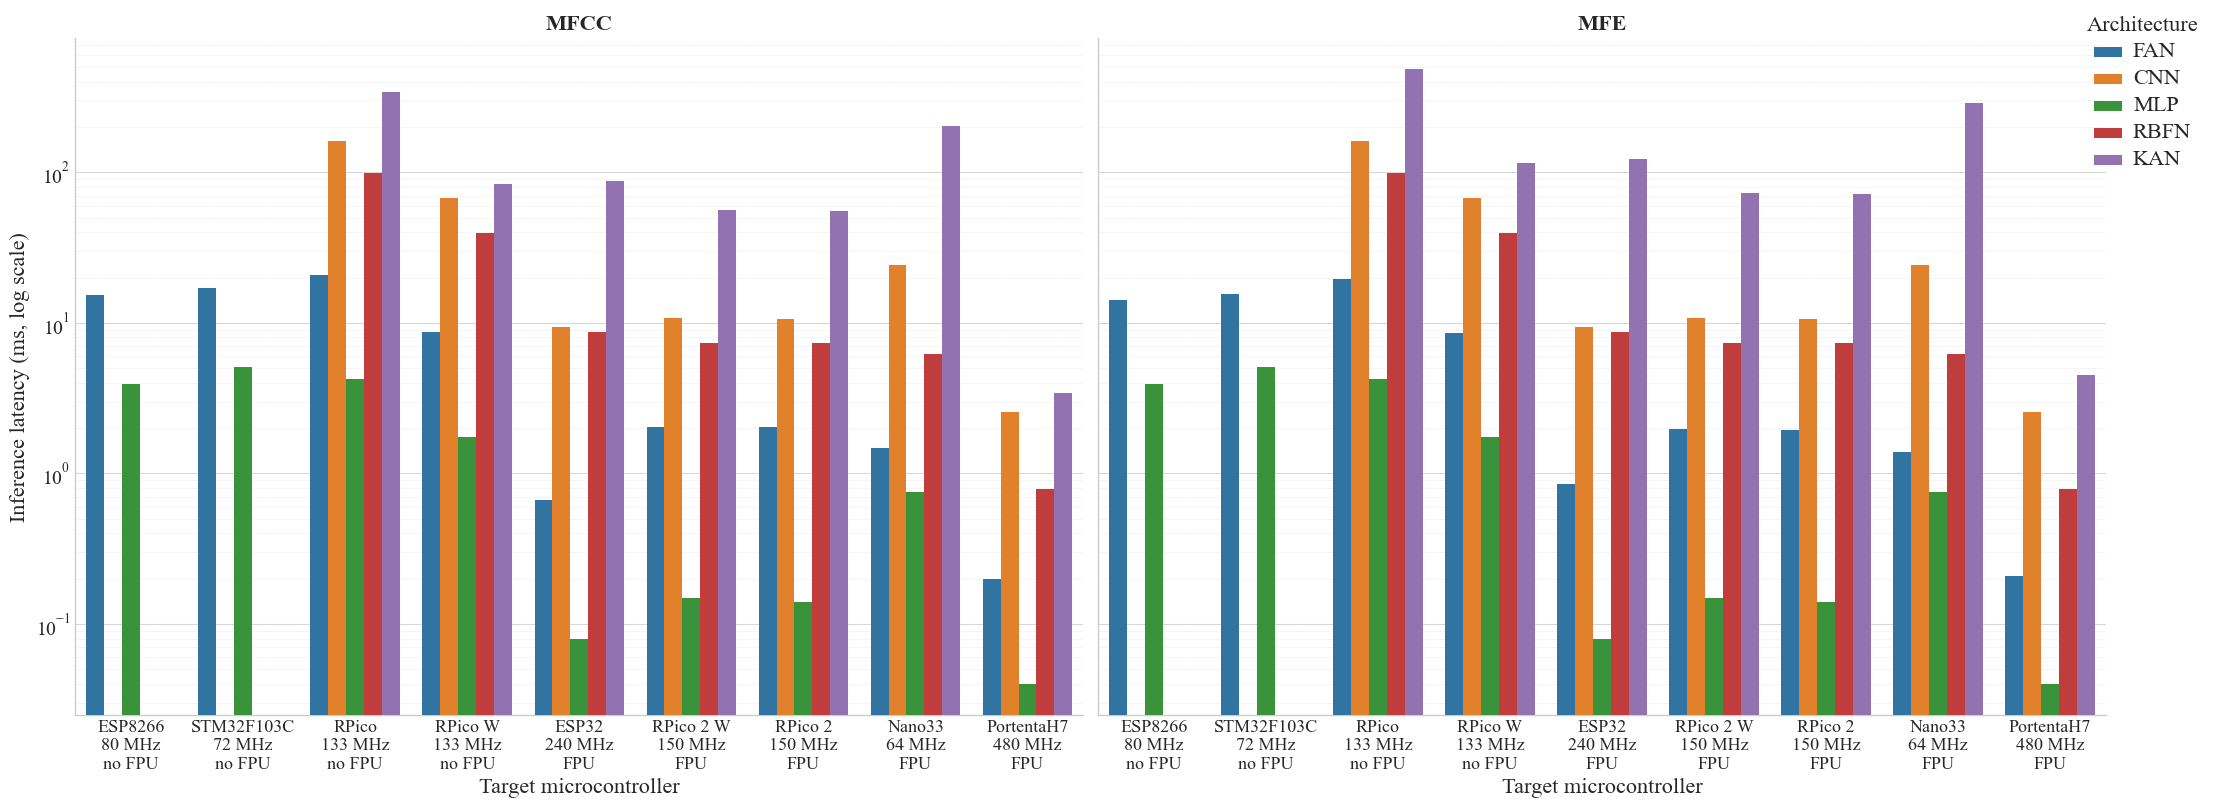

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =======================================================
# --- CONFIGURAÇÕES DO USUÁRIO ---
# =======================================================
FIG_WIDTH = 22         # Largura total da figura em polegadas
FIG_HEIGHT = 8         # Altura total da figura em polegadas
X_TICK_FONT_SIZE = 13  # Tamanho da fonte dos nomes dos microcontroladores (eixo X)
Y_TICK_FONT_SIZE = 14  # Tamanho da fonte dos números da escala (eixo Y)
LABEL_FONT_SIZE = 16   # Tamanho da fonte dos rótulos dos eixos ("Target microcontroller")
LEGEND_FONT_SIZE = 16  # Tamanho da fonte dos itens da legenda (CNN, MLP, etc.)
LEGEND_TITLE_FONT_SIZE = 16 # Tamanho da fonte do título da legenda ("Architecture")
# =======================================================

# 1. Carregar os dados
df = pd.read_csv("resultado deploys - ALL (1).csv")

# 2. Mapeamento dos nomes dos microcontroladores (com quebras de linha)
mcu_mapping = {
    'ESP8266': 'ESP8266\n80 MHz\nno FPU',
    'STM32F103C': 'STM32F103C\n72 MHz\nno FPU',
    'Raspberry Pi Pico': 'RPico\n133 MHz\nno FPU',
    'Raspberry Pi Pico W': 'RPico W\n133 MHz\nno FPU',
    'ESP32': 'ESP32\n240 MHz\nFPU',
    'Raspberry Pi Pico 2 W': 'RPico 2 W\n150 MHz\nFPU',
    'Raspberry Pi Pico 2': 'RPico 2\n150 MHz\nFPU',
    'Arduino Nano 33 BLE SENSE': 'Nano33\n64 MHz\nFPU',
    'Arduino Portenta H7': 'PortentaH7\n480 MHz\nFPU'
}
df['MCU_Label'] = df['microcontrolador'].map(mcu_mapping)

mcu_order = [
    'ESP8266\n80 MHz\nno FPU',
    'STM32F103C\n72 MHz\nno FPU',
    'RPico\n133 MHz\nno FPU',
    'RPico W\n133 MHz\nno FPU',
    'ESP32\n240 MHz\nFPU',
    'RPico 2 W\n150 MHz\nFPU',
    'RPico 2\n150 MHz\nFPU',
    'Nano33\n64 MHz\nFPU',
    'PortentaH7\n480 MHz\nFPU'
]

model_order = ['FAN', 'CNN', 'MLP', 'RBFN', 'KAN']
existing_models = [m for m in model_order if m in df['model_name'].unique()]

# 3. Substituir valores 0 por NaN para não quebrar a escala logarítmica
df['Inference time (ms)'] = df['Inference time (ms)'].replace(0, np.nan)

# 4. Aplicar configurações de fonte iniciais
plt.rcParams.update({'font.size': 10})

# O seaborn catplot usa height (altura por subplot) e aspect (largura/altura do subplot).
# Como temos 2 colunas no col="feature_type", ajustamos o aspecto dividindo a largura total por 2.
facet_height = FIG_HEIGHT
facet_aspect = (FIG_WIDTH / 2) / FIG_HEIGHT

# 5. Criar o plot agrupado
# IMPORTANTE: Definimos zorder=3 nas barras para que fiquem acima do grid (zorder=0)
g = sns.catplot(
    data=df, 
    kind="bar",
    x="MCU_Label", 
    y="Inference time (ms)", 
    hue="model_name",
    col="feature_type", 
    hue_order=existing_models,
    order=mcu_order,
    palette="tab10",
    height=facet_height, 
    aspect=facet_aspect,
    zorder=3
)

# 6. Ajustar a escala Y para logarítmica
g.set(yscale="log")

# 7. Forçar a exibição correta do Grid (Abaixo das barras e Transparente)
for ax in g.axes.flat:
    # Garante que o grid seja desenhado na camada de fundo
    ax.set_axisbelow(True)
    
    # Grid principal (10^0, 10^1, 10^2...) - mais transparente (alpha=0.3) e zorder=0
    ax.grid(True, which="major", axis="y", color="gray", linewidth=0.8, alpha=0.3, zorder=0)
    
    # Grid secundário (linhas intermediárias do log) - bem transparente (alpha=0.15) e zorder=0
    ax.grid(True, which="minor", axis="y", color="gray", linewidth=0.4, linestyle="--", alpha=0.2, zorder=0)
    
    # Desativa o grid no eixo X para ficar mais limpo visualmente
    ax.grid(False, axis="x")
    
    # Aplicar os tamanhos de fonte configurados para os eixos (nomes dos MCUs e números Y)
    ax.tick_params(axis='x', labelsize=X_TICK_FONT_SIZE)
    ax.tick_params(axis='y', labelsize=Y_TICK_FONT_SIZE)

# 8. Configuração de labels e títulos
g.set_axis_labels("Target microcontroller", "Inference latency (ms, log scale)")

# Aplicar o tamanho da fonte para os rótulos X e Y (Titles dos Eixos)
for ax in g.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel(ax.get_ylabel(), fontsize=LABEL_FONT_SIZE)

# Títulos de cada subplot: agora com NEGRITO
g.set_titles("{col_name}", size=16, fontweight='bold')

# =======================================================
# Mover e Formatar a LEGENDA
# =======================================================
# Move a legenda para o canto superior direito do grid 
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 1))

if g.legend:
    # Altera o tamanho do título ("Architecture")
    g.legend.set_title("Architecture", prop={'size': LEGEND_TITLE_FONT_SIZE})
    # Altera o tamanho dos textos dos itens ("CNN", "FAN", etc)
    plt.setp(g.legend.get_texts(), fontsize=LEGEND_FONT_SIZE)

# 9. Forçar a altura e largura exata da figura configurada pelo usuário
g.fig.set_size_inches(FIG_WIDTH, FIG_HEIGHT)

# 10. Salvar e mostrar o gráfico
plt.savefig("fig4_latency_per_mcu.pdf", bbox_inches='tight')
plt.show()

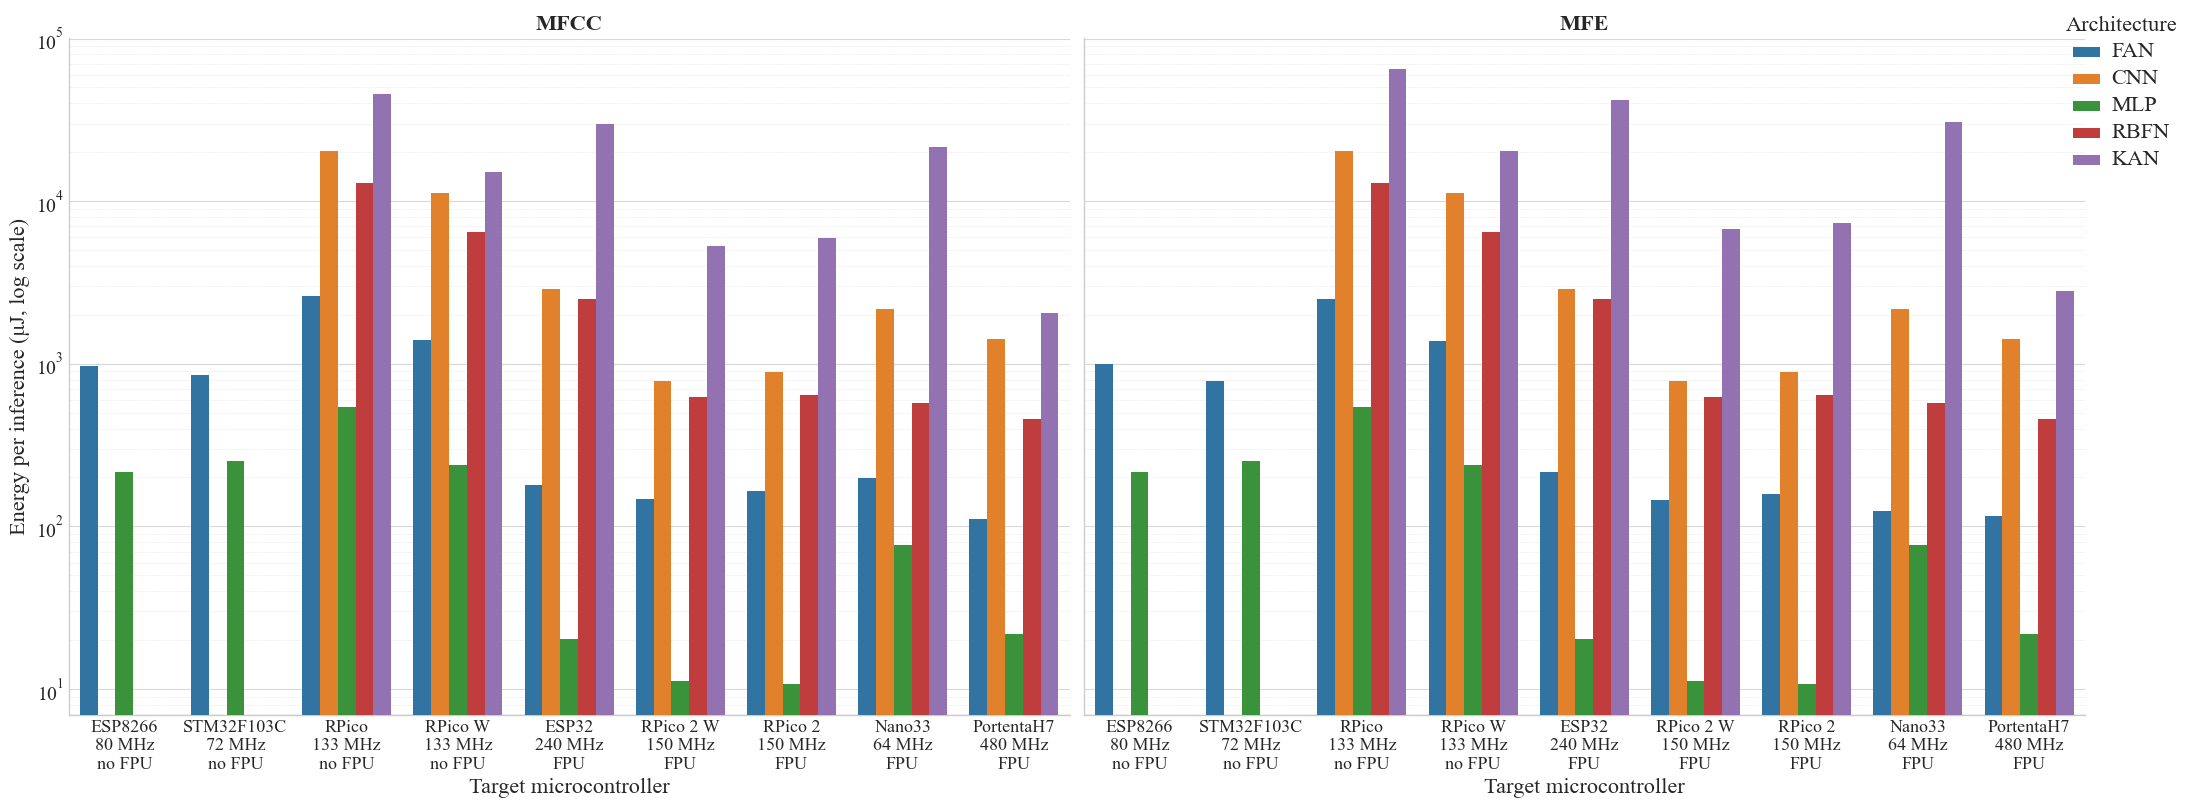

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =======================================================
# --- CONFIGURAÇÕES DO USUÁRIO ---
# =======================================================
FIG_WIDTH = 22         # Largura total da figura em polegadas
FIG_HEIGHT = 8         # Altura total da figura em polegadas
X_TICK_FONT_SIZE = 13  # Tamanho da fonte dos nomes dos microcontroladores (eixo X)
Y_TICK_FONT_SIZE = 14  # Tamanho da fonte dos números da escala (eixo Y)
LABEL_FONT_SIZE = 16   # Tamanho da fonte dos rótulos dos eixos
LEGEND_FONT_SIZE = 16  # Tamanho da fonte dos itens da legenda
LEGEND_TITLE_FONT_SIZE = 16 # Tamanho da fonte do título da legenda
# =======================================================

# 1. Carregar os dados
df = pd.read_csv("resultado deploys - ALL (1).csv")

# 2. Mapeamento dos nomes dos microcontroladores
mcu_mapping = {
    'ESP8266': 'ESP8266\n80 MHz\nno FPU',
    'STM32F103C': 'STM32F103C\n72 MHz\nno FPU',
    'Raspberry Pi Pico': 'RPico\n133 MHz\nno FPU',
    'Raspberry Pi Pico W': 'RPico W\n133 MHz\nno FPU',
    'ESP32': 'ESP32\n240 MHz\nFPU',
    'Raspberry Pi Pico 2 W': 'RPico 2 W\n150 MHz\nFPU',
    'Raspberry Pi Pico 2': 'RPico 2\n150 MHz\nFPU',
    'Arduino Nano 33 BLE SENSE': 'Nano33\n64 MHz\nFPU',
    'Arduino Portenta H7': 'PortentaH7\n480 MHz\nFPU'
}
df['MCU_Label'] = df['microcontrolador'].map(mcu_mapping)

mcu_order = [
    'ESP8266\n80 MHz\nno FPU',
    'STM32F103C\n72 MHz\nno FPU',
    'RPico\n133 MHz\nno FPU',
    'RPico W\n133 MHz\nno FPU',
    'ESP32\n240 MHz\nFPU',
    'RPico 2 W\n150 MHz\nFPU',
    'RPico 2\n150 MHz\nFPU',
    'Nano33\n64 MHz\nFPU',
    'PortentaH7\n480 MHz\nFPU'
]

model_order = ['FAN', 'CNN', 'MLP', 'RBFN', 'KAN']
existing_models = [m for m in model_order if m in df['model_name'].unique()]

# 3. Calcular a Energia por Inferência (μJ) e substituir 0 por NaN
# Energia (μJ) = Potência (mW) * Tempo (ms)
df['Energy (uJ)'] = df['Energy (mW)'] * df['Inference time (ms)']
df['Energy (uJ)'] = df['Energy (uJ)'].replace(0, np.nan)

# 4. Aplicar configurações de fonte iniciais
plt.rcParams.update({'font.size': 10})

facet_height = FIG_HEIGHT
facet_aspect = (FIG_WIDTH / 2) / FIG_HEIGHT

# 5. Criar o plot agrupado
# IMPORTANTE: Definimos zorder=3 nas barras para que fiquem acima do grid
g = sns.catplot(
    data=df, 
    kind="bar",
    x="MCU_Label", 
    y="Energy (uJ)",   # <-- ALTERADO PARA A NOVA COLUNA
    hue="model_name",
    col="feature_type", 
    hue_order=existing_models,
    order=mcu_order,
    palette="tab10",
    height=facet_height, 
    aspect=facet_aspect,
    zorder=3
)

# 6. Ajustar a escala Y para logarítmica
g.set(yscale="log")

# 7. Forçar a exibição correta do Grid (Abaixo das barras e Transparente)
for ax in g.axes.flat:
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="y", color="gray", linewidth=0.8, alpha=0.3, zorder=0)
    ax.grid(True, which="minor", axis="y", color="gray", linewidth=0.4, linestyle="--", alpha=0.2, zorder=0)
    ax.grid(False, axis="x")
    
    ax.tick_params(axis='x', labelsize=X_TICK_FONT_SIZE)
    ax.tick_params(axis='y', labelsize=Y_TICK_FONT_SIZE)

# 8. Configuração de labels e títulos
# <-- EIXO Y ALTERADO PARA MOSTRAR A NOVA UNIDADE
g.set_axis_labels("Target microcontroller", "Energy per inference (μJ, log scale)")

for ax in g.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel(ax.get_ylabel(), fontsize=LABEL_FONT_SIZE)

g.set_titles("{col_name}", size=16, fontweight='bold')

# =======================================================
# Mover e Formatar a LEGENDA
# =======================================================
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 1))

if g.legend:
    g.legend.set_title("Architecture", prop={'size': LEGEND_TITLE_FONT_SIZE})
    plt.setp(g.legend.get_texts(), fontsize=LEGEND_FONT_SIZE)

# 9. Forçar a altura e largura exata
g.fig.set_size_inches(FIG_WIDTH, FIG_HEIGHT)

# 10. Salvar e mostrar o gráfico
plt.savefig("fig5_energy_per_mcu.pdf", bbox_inches='tight')
plt.show()


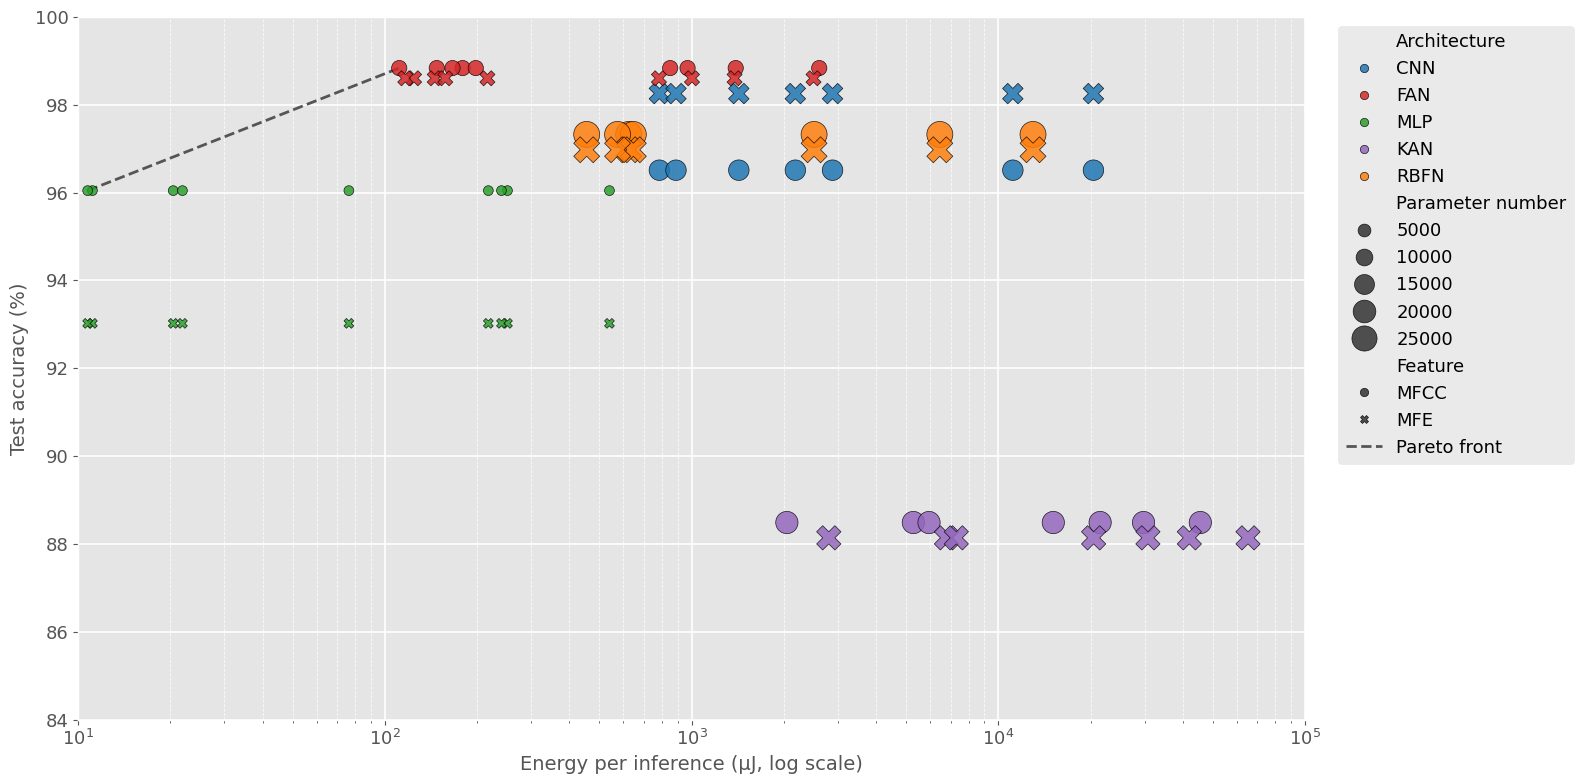

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =======================================================
# --- CONFIGURAÇÕES DO USUÁRIO ---
# =======================================================
FIG_WIDTH = 16
FIG_HEIGHT = 8
X_TICK_FONT_SIZE = 13  # Tamanho da fonte dos números do eixo X
Y_TICK_FONT_SIZE = 13  # Tamanho da fonte dos números do eixo Y
LABEL_FONT_SIZE = 14
LEGEND_FONT_SIZE = 13
# =======================================================

# 1. Carregar os dados
df = pd.read_csv("resultado deploys - ALL (1).csv")

df["Architecture"] = df["model_name"]
df["Feature"] = df["feature_type"]

# 2. Calcular a Energia por Inferência (μJ) e Acurácia (%)
df['Energy (uJ)'] = df['Energy (mW)'] * df['Inference time (ms)']
df['Accuracy (%)'] = df['Accuracy'] * 100
df = df[df['Energy (uJ)'] > 0].copy()

# 3. Fronteira de Pareto
df_sorted = df.sort_values(by=['Energy (uJ)', 'Accuracy (%)'], ascending=[True, False])
pareto_front = []
max_acc = -1

for index, row in df_sorted.iterrows():
    if row['Accuracy (%)'] > max_acc:
        pareto_front.append(row)
        max_acc = row['Accuracy (%)']

pareto_df = pd.DataFrame(pareto_front)

# =======================================================
# 4. Configurar Estilo GGPLOT Clássico
# =======================================================
# Reseta qualquer tema anterior do seaborn que possa forçar o fundo branco
sns.reset_orig() 
plt.style.use('ggplot')
plt.rcParams.update({'font.size': 12})

# 5. Definir Paleta Customizada
custom_palette = {
    'FAN': '#d62728',   # Vermelho forte
    'CNN': '#1f77b4',   # Azul
    'MLP': '#2ca02c',   # Verde
    'RBFN': '#ff7f0e',  # Laranja
    'KAN': '#9467bd'    # Roxo
}

# Criar a figura e o eixo
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

# FORÇAR O FUNDO CINZA DO GGPLOT EXPLICITAMENTE
ax.set_facecolor('#E5E5E5') # Cinza claro clássico do ggplot
fig.patch.set_facecolor('white') # Borda externa da figura branca

# 6. Scatterplot
sns.scatterplot(
    data=df, 
    x="Energy (uJ)", 
    y="Accuracy (%)", 
    hue="Architecture", 
    style="Feature",
    size="Parameter number",
    sizes=(50, 350),
    palette=custom_palette,
    alpha=0.85,
    edgecolor="black", # Adiciona um leve contorno aos pontos
    linewidth=0.5,
    zorder=3,
    ax=ax
)

# 7. Linha da Fronteira de Pareto
ax.plot(
    pareto_df['Energy (uJ)'], 
    pareto_df['Accuracy (%)'], 
    linestyle='--', 
    color='#555555', # Cinza escuro para dar contraste com o fundo cinza
    linewidth=2, 
    label='Pareto front',
    zorder=2
)

# Escalas e Rótulos
ax.set_xscale("log")
ax.set_xlim(10**1, 10**5)
ax.set_ylim(84, 100)
ax.set_xlabel("Energy per inference (μJ, log scale)", fontsize=LABEL_FONT_SIZE)
ax.set_ylabel("Test accuracy (%)", fontsize=LABEL_FONT_SIZE)

# =======================================================
# 8. Ajustes de Fonte dos Eixos (Ticks) e Grid Logarítmico
# =======================================================
ax.tick_params(axis='x', labelsize=X_TICK_FONT_SIZE)
ax.tick_params(axis='y', labelsize=Y_TICK_FONT_SIZE)

# Garantir que o grid seja desenhado atrás dos pontos do gráfico
ax.set_axisbelow(True)

# Grid com linhas BRANCAS para destacar no fundo cinza
ax.grid(True, which="major", axis="x", color="white", linewidth=1.2, zorder=0)
ax.grid(True, which="minor", axis="x", color="white", linewidth=0.6, linestyle="--", alpha=0.8, zorder=0)
ax.grid(True, which="major", axis="y", color="white", linewidth=1.2, zorder=0)

# =======================================================
# 9. Legenda Integrada ao Fundo
# =======================================================
handles, labels = ax.get_legend_handles_labels()

# Define facecolor com a mesma cor de fundo dos eixos do ggplot e borda idêntica
ax.legend(
    handles, 
    labels, 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    fontsize=LEGEND_FONT_SIZE, 
    frameon=True, 
    facecolor=ax.get_facecolor(), # Fundo da legenda igual ao fundo do gráfico
    edgecolor=ax.get_facecolor()  # Borda invisível (mesma cor do fundo)
)

plt.tight_layout()

# Salvar e mostrar
plt.savefig("fig6_pareto_acc_energy.pdf", bbox_inches='tight')
plt.show()